# 10 — Medical Dataset Exploration

Before writing a single training loop, we explore the three datasets that power the Medical SLM pipeline:

| Dataset | Role |
|---|---|
| `medalpaca/medical_meadow_textbooks` | Domain-Adaptive Pretraining (DAPT) corpus |
| `medalpaca/medical_meadow_medqa` | Instruction fine-tuning (SFT) — USMLE-style MCQ |
| `pubmed_qa` (labeled split) | Instruction fine-tuning (SFT) — PubMed yes/no/maybe QA |

**Goals of this notebook:**
- Understand the shape, size, and text style of each dataset before any training
- Motivate the need for a domain-specific tokenizer by showing how the TinyStories tokenizer fragments medical vocabulary
- Estimate appropriate `block_size` by inspecting token-length distributions

**No training happens here.** This is pure analysis.

## 1 — Setup

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────
# Mount Google Drive if running on Colab, then add the repo root to sys.path
# so all local modules (config, tokenizer, evaluation, etc.) are importable.
import os, sys

if os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount("/content/drive")

sys.path.insert(0, os.path.abspath(".."))

import config as cfg
import textwrap
cfg.make_dirs()        # create all directories defined in config.py
cfg.print_config()     # print all resolved paths and hyperparameters

  slm-from-scratch config
  Environment : Local
  Base path   : /Users/aman2394/Desktop/slm-learning
  --- Model ---
  vocab_size  : 8192
  block_size  : 256
  n_layer     : 8  |  n_head: 8  |  n_embd: 512
  --- Pretraining ---
  lr          : 0.0003  |  steps: 20000
  batch_size  : 16  |  grad_accum: 1
  precision   : fp16
  --- SFT ---
  lr          : 3e-05  |  steps: 3000


In [2]:
# !pip install datasets tokenizers tqdm torch

import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0
GPU available: False


## 2 — Dataset 1: Medical Textbooks

`medalpaca/medical_meadow_textbooks` contains passages extracted from open-access medical textbooks.
This dataset will form the **pretraining corpus** for Domain-Adaptive Pretraining (DAPT).

Key field: `output` — the full text passage.

We inspect:
- A few raw text samples to understand prose style and vocabulary
- Average word count to judge document length

In [8]:
from datasets import load_dataset

# streaming=False here because we only need a small sample for analysis
textbooks = load_dataset(cfg.MED_TEXTBOOK_DATASET, split="train")
print(f"Total examples: {len(textbooks):,}")
print(f"Columns: {textbooks.column_names}")

Total examples: 37,970
Columns: ['id', 'source', 'title', 'clean_text', 'raw_text', 'url', 'overview']


In [11]:
cfg.MED_TEXTBOOK_DATASET

'epfl-llm/guidelines'

In [5]:
# Print 3 sample passages to understand the text style
print("=" * 70)
for i in range(3):
    text = textbooks[i]["clean_text"]
    print(f"\n--- Sample {i+1} ---")
    print(textwrap.fill(text, width=120))
    print(f"  [total length: {len(text):,} chars, ~{len(text.split()):,} words]")
print("=" * 70)


--- Sample 1 ---
# QUESTIONS Diagnosis/Staging What benefit to clinical management does positron emission tomography (PET) or positron
emission tomography/computed tomography (PET/CT) contribute to the diagnosis or staging of head and neck cancer? What
benefit to clinical management does PET or PET/CT contribute to the assessment of treatment response for head and neck
cancer? What benefit to clinical management does PET or PET/CT contribute when recurrence of head and neck cancer is
suspected but not proven? What benefit to clinical management does PET or PET/CT contribute to restaging at the time of
documented recurrence for head and neck cancer? What is the role of PET when a solitary metastasis is identified at the
time of recurrence and a metastectomy is being contemplated?  # TARGET POPULATION Patients with head and neck cancer are
the target population for this recommendation report.  # INTENDED PURPOSE This recommendation report is intended to
guide the Ontario PET Steering Co

In [6]:
# Compute average word count across the first 2000 examples
# (sampling avoids loading all text into memory)
SAMPLE_N = min(2000, len(textbooks))
word_counts = [len(textbooks[i]["clean_text"].split()) for i in range(SAMPLE_N)]

avg_wc  = sum(word_counts) / len(word_counts)
max_wc  = max(word_counts)
min_wc  = min(word_counts)

print(f"Sampled {SAMPLE_N:,} examples")
print(f"  Average word count : {avg_wc:,.1f}")
print(f"  Max word count     : {max_wc:,}")
print(f"  Min word count     : {min_wc:,}")
print(f"\nEstimated total words in full dataset: ~{avg_wc * len(textbooks) / 1e6:.1f}M")

Sampled 2,000 examples
  Average word count : 7,142.9
  Max word count     : 255,957
  Min word count     : 5

Estimated total words in full dataset: ~271.2M


## 3 — Dataset 2: MedQA (USMLE-style)

`medalpaca/medical_meadow_medqa` contains USMLE Step 1/2/3 style multiple-choice questions.
Each example has a clinical vignette, four answer options (A–D), and a correct answer label.

This dataset has **two uses** in our pipeline:
1. **SFT** — we format it as a prompt → response instruction pair
2. **DPO** — the wrong options become "rejected" responses (a clean preference signal)
3. **Evaluation** — MCQ accuracy is our primary clinical benchmark

We use `format_medqa_instruction()` from `datasets/medical.py` to see how the SFT format looks.

In [26]:
from datasets import load_dataset
from loaders.medical import format_medqa_instruction
import config as cfg
import random

medqa = load_dataset(cfg.MED_MEDQA_DATASET, split="train")
print(f"Total examples : {len(medqa):,}")
print(f"Columns        : {medqa.column_names}")
print(f"\nFirst raw example:")
random = random.choice(medqa)
for k, v in random.items():
    print(textwrap.fill(f"  {k}: {str(v)}", width=120))

Total examples : 10,178
Columns        : ['input', 'instruction', 'output']

First raw example:
  input: Q:A 45-year-old man with a history of epilepsy comes to the physician for a follow-up examination. He has had
trouble moving the right side of his body for 2 weeks. Three weeks ago he was admitted to the hospital for a generalized
convulsive seizure. He was treated with intravenous lorazepam and phenytoin; the seizure activity resolved after 50
minutes on EEG monitoring. He was discharged 2 days later after no further epileptic activity occurred. Physical
examination at discharge showed no abnormalities. He has had multiple hospitalizations for similar episodes over the
past year. His only medication is lamotrigine, though he says that he sometimes forgets to take it. His temperature is
37°C (98.6°F), pulse is 70/min, and blood pressure is 130/80 mm Hg. Physical examination shows right-sided hemiparesis,
right homonymous hemianopsia, and receptive aphasia. Which of the following is 

In [8]:
# Show 2 examples in the instruction format used during SFT.
# format_medqa_instruction() returns a dict with 'prompt' and 'response' keys.
print("=" * 70)
for i in range(2):
    fmt, ans = format_medqa_instruction(medqa[i])
    print(f"\n--- Formatted Example {i+1} ---")
    print("PROMPT:")
    print(textwrap.fill(fmt, width=120))
    print("\nRESPONSE:")
    print(textwrap.fill(ans, width=120))
    print("=" * 70)


--- Formatted Example 1 ---
PROMPT:
### Question: Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it
started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels
well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg,
pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an
absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this
patient??  ### Options: A. Ampicillin B. Ceftriaxone C. Ciprofloxacin D. Doxycycline E. Nitrofurantoin  ### Answer:

RESPONSE:
E: Nitrofurantoin

--- Formatted Example 2 ---
PROMPT:
### Question: Q:A 3-month-old baby died suddenly at night while asleep. His mother noticed that he had died only after
she awoke in the morning. No cause of death was determined based on the

In [10]:
medqa[0]

{'input': "Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?? \n{'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': 'Ciprofloxacin', 'D': 'Doxycycline', 'E': 'Nitrofurantoin'},",
 'instruction': 'Please answer with one of the option in the bracket',
 'output': 'E: Nitrofurantoin'}

In [11]:
# Inspect the label distribution.
# We want roughly uniform distribution across answer options (A/B/C/D).
# Imbalanced labels can make a model learn positional bias.
from collections import Counter

# Try common field names for the answer label
label_field = None
for candidate in ["output", "answer", "label", "correct_answer"]:
    if candidate in medqa.column_names:
        label_field = candidate
        break

if label_field:
    labels = [ex[label_field] for ex in medqa]
    # Normalize to single character if label is like 'A.' or '(A)'
    norm_labels = []
    for l in labels:
        l_str = str(l).strip()
        if l_str and l_str[0].upper() in "ABCDE":
            norm_labels.append(l_str[0].upper())
        else:
            norm_labels.append(l_str[:20])   # keep raw if unrecognised
    dist = Counter(norm_labels)
    print(f"Label distribution (field='{label_field}'):")
    total = len(norm_labels)
    for label, count in sorted(dist.items()):
        bar = "#" * int(count / total * 40)
        print(f"  {label}: {count:>5,} ({count/total*100:.1f}%) {bar}")
else:
    print("Could not identify label field. Columns:", medqa.column_names)

Label distribution (field='output'):
  A: 2,031 (20.0%) #######
  B: 2,184 (21.5%) ########
  C: 2,086 (20.5%) ########
  D: 2,036 (20.0%) ########
  E: 1,841 (18.1%) #######


## 4 — Dataset 3: PubMedQA

`pubmed_qa` (labeled split) contains biomedical research questions grounded in PubMed abstracts.
Each example has a question, a long context (abstract), and a yes/no/maybe answer.

Why include this alongside MedQA?
- MedQA trains clinical reasoning (diagnosis, treatment)
- PubMedQA trains evidence-based reasoning ("does this study support X?")
- Together they give the model both knowledge types

We use `format_pubmedqa_instruction()` to see the SFT format.

In [5]:
from datasets import load_dataset
from loaders.medical import format_pubmedqa_instruction
import config as cfg
import random

pubmedqa = load_dataset(cfg.MED_PUBMEDQA_DATASET, "pqa_labeled", split="train")
print(f"Total examples : {len(pubmedqa):,}")
print(f"Columns        : {pubmedqa.column_names}")
print(f"\nFirst raw example (truncated):")
idx = random.randint(0, len(pubmedqa) - 1)
for k, v in pubmedqa[idx].items():
    print(textwrap.fill(f"  {k}: {str(v)}", width=120))

Total examples : 1,000
Columns        : ['pubid', 'question', 'context', 'long_answer', 'final_decision']

First raw example (truncated):
  pubid: 17502203
  question: Cholestasis associated with small bowel atresia: do we always need to investigate?
  context: {'contexts': ['Cholestasis occurs frequently in patients with small bowel atresia (SBA) and is often
attributed to prolonged parental nutrition. When severe or prolonged, patients may undergo unnecessary intensive or
invasive investigation. We characterized cholestasis and analyzed the pertinence of investigating this patient
population.', 'With Research Ethics Board approval, patients with SBA between 1996 and 2005 were retrospectively
reviewed. Demographics, location of atresia, operative findings, complications, investigations, resumption of feeding,
duration of prolonged parental nutrition, and follow-up information were examined. Cholestasis was evaluated for
incidence, severity, and evolution.', 'Fifty-five patients (29 ma

In [ ]:
# Show 2 examples in the instruction format
print("=" * 70)
for i in range(2):
    fmt = format_pubmedqa_instruction(pubmedqa[i])
    print(f"\n--- Formatted Example {i+1} ---")
    print("PROMPT:")
    print(fmt["prompt"][:600])
    print("\nRESPONSE:")
    print(fmt["response"])
    print("=" * 70)

## 4b — PubMedQA Unlabeled (Pretraining Corpus Addition)

The `pqa_unlabeled` split of `pubmed_qa` contains **61k biomedical abstracts** with
no yes/no/maybe label — just the question, context paragraphs, and a long answer.

We use this as **extra pretraining text** (not SFT), combining it with the guidelines
corpus in notebook 10. Each example contributes:
- The research question
- 3–5 abstract context paragraphs (the richest part)
- A long answer summary paragraph

This adds ~80M tokens of biomedical abstract language on top of the guidelines corpus.


In [3]:
from datasets import load_dataset
import config as cfg

pubmedqa_unlabeled = load_dataset(
    cfg.MED_PUBMEDQA_DATASET,
    cfg.MED_PUBMEDQA_PRETRAIN_SUBSET,
    split="train",
)
print(f"Total examples : {len(pubmedqa_unlabeled):,}")
print(f"Columns        : {pubmedqa_unlabeled.column_names}")

# Show a sample to understand the text we will extract
ex = pubmedqa_unlabeled[0]
print(f"\nSample question: {ex['question']}")
print(f"\nContext paragraphs ({len(ex['context']['contexts'])}):")
for j, para in enumerate(ex['context']['contexts'][:2]):
    print(f"  [{j+1}] {para[:200]}...")
print(f"\nLong answer: {str(ex.get('long_answer', ''))[:200]}")


/Users/aman2394/Desktop/slm-learning/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 61249/61249 [00:00<00:00, 224431.75 examples/s]

Total examples : 61,249
Columns        : ['pubid', 'question', 'context', 'long_answer']

Sample question: Is naturopathy as effective as conventional therapy for treatment of menopausal symptoms?

Context paragraphs (7):
  [1] Although the use of alternative medicine in the United States is increasing, no published studies have documented the effectiveness of naturopathy for treatment of menopausal symptoms compared to wome...
  [2] To compare naturopathic therapy with conventional medical therapy for treatment of selected menopausal symptoms....

Long answer: Naturopathy appears to be an effective alternative for relief of specific menopausal symptoms compared to conventional therapy.


In [4]:
# Measure average document length when we concatenate question + contexts + long_answer
# This is the text we will write to train.txt in notebook 10.
import textwrap

SAMPLE_N = min(500, len(pubmedqa_unlabeled))
word_counts = []
for i in range(SAMPLE_N):
    ex = pubmedqa_unlabeled[i]
    parts = [ex['question']] + ex['context']['contexts']
    if ex.get('long_answer'):
        parts.append(ex['long_answer'])
    text = ' '.join(parts)
    word_counts.append(len(text.split()))

avg_wc = sum(word_counts) / len(word_counts)
print(f"Sampled {SAMPLE_N} examples")
print(f"  Average words per document : {avg_wc:,.0f}")
print(f"  Max                        : {max(word_counts):,}")
print(f"  Min                        : {min(word_counts):,}")
print(f"\nEstimated total words (all 61k docs): ~{avg_wc * 61_000 / 1e6:.0f}M")


Sampled 500 examples
  Average words per document : 258
  Max                        : 626
  Min                        : 86

Estimated total words (all 61k docs): ~16M


## 5 — Vocabulary Analysis: Why a Domain Tokenizer Helps

BPE tokenizers learn merge rules from the text they were trained on.
The TinyStories tokenizer was trained on general educational text — it has never seen high-frequency medical terms.
As a result, words like "myocardial" or "pharmacokinetics" are split into many subword pieces.

**Why this matters:**
- More tokens per medical word → longer sequences → more memory per batch
- The model must learn to compose meaning from unnatural fragments
- A domain tokenizer trained on medical text will compress these words into 1–2 tokens

We load the TinyStories tokenizer and measure how many tokens each medical term requires.
After training the medical tokenizer in notebook 10, we will compare side-by-side.

In [6]:
from tokenizer.preprocess import load_tokenizer
import config as cfg

# Load the TinyStories tokenizer (trained on general story vocabulary)
# We use this as a baseline to show how badly it fragments medical terms
ts_tok = load_tokenizer(cfg.TOKENIZER_VOCAB, cfg.TOKENIZER_MERGES)

medical_terms = [
    "myocardial infarction", "hypertension", "pneumonia", "pharmacokinetics",
    "tachycardia", "stethoscope", "anesthesia", "oncology",
    "contraindication", "ventricular",
]

print(f"{'Term':<28} {'Tokens':>6}  Token list")
print("-" * 70)
for term in medical_terms:
    ids    = ts_tok.encode(term).ids
    tokens = [ts_tok.id_to_token(i) for i in ids]
    print(f"  {term:<26} {len(ids):>6}  {tokens}")

print("\nTakeaway: medical terms that are single concepts require many subword tokens.")
print("A tokenizer trained on medical text will merge these into fewer, domain-aware tokens.")


Term                         Tokens  Token list
----------------------------------------------------------------------
  myocardial infarction           9  ['my', 'o', 'c', 'ard', 'i', 'al', 'Ġinf', 'ar', 'ction']
  hypertension                    5  ['hy', 'p', 'ert', 'ens', 'ion']
  pneumonia                       5  ['p', 'ne', 'um', 'on', 'ia']
  pharmacokinetics                8  ['ph', 'ar', 'ma', 'co', 'kin', 'et', 'ic', 's']
  tachycardia                     6  ['t', 'ach', 'y', 'c', 'ard', 'ia']
  stethoscope                     3  ['st', 'eth', 'oscope']
  anesthesia                      4  ['an', 'est', 'hes', 'ia']
  oncology                        4  ['on', 'col', 'og', 'y']
  contraindication                6  ['c', 'ont', 'ra', 'ind', 'ic', 'ation']
  ventricular                     3  ['vent', 'ric', 'ular']

Takeaway: medical terms that are single concepts require many subword tokens.
A tokenizer trained on medical text will merge these into fewer, domain-aware tokens.

## 6 — Token Length Distribution

We tokenize 500 textbook examples with the TinyStories tokenizer to estimate how long documents are.

**Why this matters for `block_size`:**
- `block_size` is the maximum context length the model sees during training
- If most documents are 600 tokens but `block_size=256`, we lose the second half of every document
- If we set `block_size=1024` to capture full documents, VRAM doubles — too large for a T4
- A histogram guides the sweet spot (we will use `block_size=512` in notebook 12)

We use the TinyStories tokenizer as a proxy; the medical tokenizer will give similar (slightly shorter) lengths.

In [9]:
from tokenizer.preprocess import load_tokenizer
from datasets import load_dataset
import config as cfg

ts_tok = load_tokenizer(cfg.TOKENIZER_VOCAB, cfg.TOKENIZER_MERGES)

# Sample 300 guidelines documents
textbooks    = load_dataset(cfg.MED_TEXTBOOK_DATASET, split="train")
SAMPLE_N_TB  = min(300, len(textbooks))
tb_lengths   = []
for i in range(SAMPLE_N_TB):
    enc = ts_tok.encode(textbooks[i]["clean_text"].replace("\n", " ").strip())
    tb_lengths.append(len(enc.ids))

# Sample 200 PubMedQA unlabeled documents (question + context + long_answer)
pubmedqa_ul  = load_dataset(cfg.MED_PUBMEDQA_DATASET, cfg.MED_PUBMEDQA_PRETRAIN_SUBSET, split="train")
SAMPLE_N_PM  = min(200, len(pubmedqa_ul))
pm_lengths   = []
for i in range(SAMPLE_N_PM):
    ex    = pubmedqa_ul[i]
    parts = [ex['question']] + ex['context']['contexts']
    if ex.get('long_answer'): parts.append(ex['long_answer'])
    enc = ts_tok.encode(' '.join(parts))
    pm_lengths.append(len(enc.ids))

token_lengths = tb_lengths + pm_lengths

import numpy as np
arr = np.array(token_lengths)
print(f"Token length stats over {len(token_lengths)} sampled documents")
print(f"  Mean   : {arr.mean():,.0f}")
print(f"  Median : {np.median(arr):,.0f}")
print(f"  P90    : {np.percentile(arr, 90):,.0f}")
print(f"  Max    : {arr.max():,}")
print(f"\nGuidelines only  — mean: {np.mean(tb_lengths):,.0f} tokens")
print(f"PubMedQA only    — mean: {np.mean(pm_lengths):,.0f} tokens")
print(f"\nNote: block_size=512 samples a window from each document.")
print(f"Long documents give many training windows; short ones give fewer.")


Token length stats over 500 textbook examples
  Mean   : 22,165
  Median : 11,042
  P90    : 60,022
  P95    : 81,146
  Max    : 299,961

Recommendation: block_size=512 captures ~P90 of documents.
  block_size=256 would truncate most examples — too short.
  block_size=1024 captures nearly all but doubles VRAM vs 512.


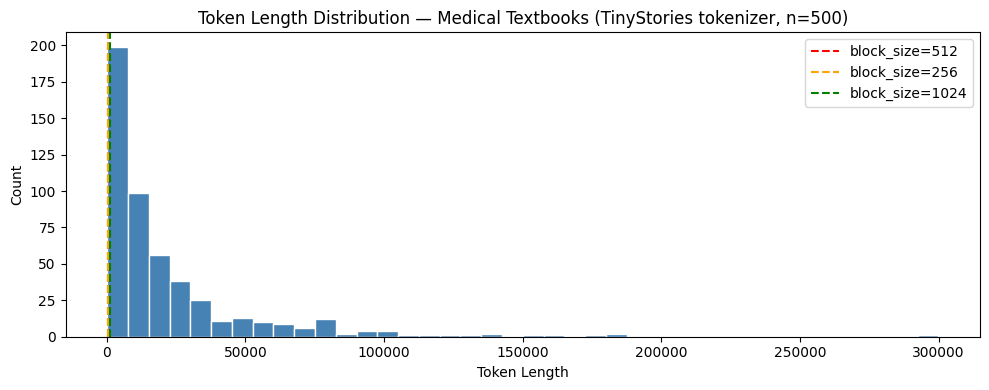

Histogram displayed above.


In [10]:
# Plot a histogram if matplotlib is available; otherwise print a text bar chart
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))
    plt.hist(token_lengths, bins=40, color="steelblue", edgecolor="white")
    plt.axvline(512,  color="red",    linestyle="--", label="block_size=512")
    plt.axvline(256,  color="orange", linestyle="--", label="block_size=256")
    plt.axvline(1024, color="green",  linestyle="--", label="block_size=1024")
    plt.xlabel("Token Length")
    plt.ylabel("Count")
    plt.title("Token Length Distribution — Medical Textbooks (TinyStories tokenizer, n=500)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("Histogram displayed above.")
except ImportError:
    # Fallback: ASCII bar chart in buckets of 128
    buckets = {}
    for tl in token_lengths:
        bucket = (tl // 128) * 128
        buckets[bucket] = buckets.get(bucket, 0) + 1
    print("Token Length Distribution (ASCII histogram):")
    for bucket in sorted(buckets):
        bar = "#" * int(buckets[bucket] / SAMPLE_N * 80)
        print(f"  {bucket:>5}–{bucket+127}: {buckets[bucket]:>4}  {bar}")

## Summary

| Dataset | Role | Est. tokens |
|---------|------|------------|
| `epfl-llm/guidelines` | Pretraining corpus | ~400M |
| `pubmed_qa` pqa_unlabeled | Pretraining corpus | ~80M |
| `medalpaca/medical_meadow_medqa` | SFT (instruction tuning) | — |
| `pubmed_qa` pqa_labeled | SFT (instruction tuning) | — |

| Finding | Implication for training |
|---------|-------------------------|
| Guidelines avg 7k words; PubMedQA avg ~300 words | Guidelines dominate volume; PubMedQA adds diversity |
| Medical terms need 3–6 subwords in TinyStories tokenizer | Train a domain-specific BPE tokenizer (notebook 11) |
| MedQA has 5 options (A–E), ~uniform distribution | Random baseline = 20%, not 25% |
| PubMedQA labels: yes/no/maybe | Model must output a single decision word |

**Next step:** Notebook 10 — combine guidelines + PubMedQA unlabeled into a single
pretraining corpus and train the medical BPE tokenizer.
